# Algeria Economic Analysis and International Comparison

This notebook analyzes Algeria's economic performance and resource indicators, comparing them with other countries to identify strengths and areas for improvement.

**All visualizations are automatically saved to the `figures/` directory for use in the report.**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries imported successfully')
print('📁 Figures will be saved to: figures/')

✅ Libraries imported successfully
📁 Figures will be saved to: figures/


## 1. Load Cleaned Datasets

In [16]:
# Load the cleaned datasets (not normalized or standardized)
economic_df = pd.read_csv('data/cleaned/clean_economic_indicators_cleaned.csv')
resources_df = pd.read_csv('data/cleaned/resources_human_capital_cleaned.csv')

print(f'📊 Economic Indicators Dataset: {economic_df.shape}')
print(f'📊 Resources & Human Capital Dataset: {resources_df.shape}')
print(f'\n🌍 Total countries in economic dataset: {len(economic_df)}')
print(f'🌍 Total countries in resources dataset: {len(resources_df)}')

📊 Economic Indicators Dataset: (263, 66)
📊 Resources & Human Capital Dataset: (229, 86)

🌍 Total countries in economic dataset: 263
🌍 Total countries in resources dataset: 229


## 2. Extract Algeria's Data

In [17]:
# Find Algeria in both datasets
algeria_economic = economic_df[economic_df['Country'].str.contains('Algeria', case=False, na=False)]
algeria_resources = resources_df[resources_df['Country'].str.contains('Algeria', case=False, na=False)]

print(f'🇩🇿 Algeria found in economic dataset: {len(algeria_economic) > 0}')
print(f'🇩🇿 Algeria found in resources dataset: {len(algeria_resources) > 0}')

if len(algeria_economic) > 0:
    print(f'\n📍 Algeria country name in economic dataset: "{algeria_economic["Country"].values[0]}"')
if len(algeria_resources) > 0:
    print(f'📍 Algeria country name in resources dataset: "{algeria_resources["Country"].values[0]}"')

🇩🇿 Algeria found in economic dataset: True
🇩🇿 Algeria found in resources dataset: True

📍 Algeria country name in economic dataset: "Algeria"
📍 Algeria country name in resources dataset: "Algeria"


## 3. Calculate Algeria's Percentile Rankings

For each indicator, we calculate Algeria's percentile ranking compared to all countries. A higher percentile means better performance.

In [18]:
def calculate_percentile_rankings(df, country_name):
    """
    Calculate percentile rankings for a country across all numeric indicators.
    Returns a dataframe with indicator names and their percentile rankings.
    """
    # Get the country's data
    country_data = df[df['Country'].str.contains(country_name, case=False, na=False)]
    
    if len(country_data) == 0:
        print(f'⚠️ {country_name} not found in dataset')
        return None
    
    # Get numeric columns only (exclude Country)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    percentile_data = []
    
    for col in numeric_cols:
        country_value = country_data[col].values[0]
        
        # Calculate percentile (percentage of countries with lower values)
        all_values = df[col].dropna()
        if len(all_values) > 0:
            percentile = (all_values < country_value).sum() / len(all_values) * 100
            
            percentile_data.append({
                'Indicator': col,
                'Algeria_Value': country_value,
                'Percentile': percentile,
                'Countries_Below': (all_values < country_value).sum(),
                'Total_Countries': len(all_values)
            })
    
    return pd.DataFrame(percentile_data)

# Calculate percentiles for both datasets
print('🔍 Calculating percentile rankings for Algeria...')
algeria_economic_rankings = calculate_percentile_rankings(economic_df, 'Algeria')
algeria_resources_rankings = calculate_percentile_rankings(resources_df, 'Algeria')

print(f'\n✅ Economic indicators analyzed: {len(algeria_economic_rankings)}')
print(f'✅ Resources & human capital indicators analyzed: {len(algeria_resources_rankings)}')

🔍 Calculating percentile rankings for Algeria...

✅ Economic indicators analyzed: 65
✅ Resources & human capital indicators analyzed: 85


## 4. Identify Top Strengths and Weaknesses

### Dataset 1: Economic Indicators

In [19]:
# Sort by percentile to find strengths (high percentile) and weaknesses (low percentile)
algeria_economic_sorted = algeria_economic_rankings.sort_values('Percentile', ascending=False)

# Top 15 strengths (economic indicators)
print('🌟 TOP 15 ECONOMIC STRENGTHS (High Percentile = Good Performance)\n')
print('='*100)
top_economic_strengths = algeria_economic_sorted.head(15)
for idx, row in top_economic_strengths.iterrows():
    print(f'{row["Indicator"][:70]:<70} | Value: {row["Algeria_Value"]:>10.2f} | Percentile: {row["Percentile"]:>5.1f}%')

print('\n' + '='*100)
print('\n⚠️ TOP 15 ECONOMIC WEAKNESSES (Low Percentile = Poor Performance)\n')
print('='*100)
top_economic_weaknesses = algeria_economic_sorted.tail(15)
for idx, row in top_economic_weaknesses.iterrows():
    print(f'{row["Indicator"][:70]:<70} | Value: {row["Algeria_Value"]:>10.2f} | Percentile: {row["Percentile"]:>5.1f}%')

🌟 TOP 15 ECONOMIC STRENGTHS (High Percentile = Good Performance)

Structure_Exports_Fuels_% of total_2015                                | Value:      95.80 | Percentile:  99.2%
Unemployment_Unemployment, youth female (% of female labor force ages  | Value:      51.12 | Percentile:  96.6%
Unemployment_Unemployment, female (% of female labor force) (modeled I | Value:      23.35 | Percentile:  95.1%
Unemployment_Unemployment, youth female (% of female labor force ages  | Value:      45.22 | Percentile:  94.7%
GDP_Growth_Manufacturing_average annual real growth (%)_2020-2024      | Value:       7.70 | Percentile:  92.8%
Structure_Value_Industry_% of GDP_2024                                 | Value:      37.80 | Percentile:  90.5%
Unemployment_Unemployment, youth male (% of male labor force ages 15-2 | Value:      30.66 | Percentile:  89.4%
GDP_Growth_Agriculture_average annual real growth (%)_2010-2020        | Value:       4.20 | Percentile:  87.5%
Unemployment_Unemployment, female (% o

### Dataset 2: Resources and Human Capital

In [20]:
# Sort by percentile for resources dataset
algeria_resources_sorted = algeria_resources_rankings.sort_values('Percentile', ascending=False)

# Top 15 strengths (resources)
print('🌟 TOP 15 RESOURCES & HUMAN CAPITAL STRENGTHS\n')
print('='*100)
top_resources_strengths = algeria_resources_sorted.head(15)
for idx, row in top_resources_strengths.iterrows():
    print(f'{row["Indicator"][:70]:<70} | Value: {row["Algeria_Value"]:>10.2f} | Percentile: {row["Percentile"]:>5.1f}%')

print('\n' + '='*100)
print('\n⚠️ TOP 15 RESOURCES & HUMAN CAPITAL WEAKNESSES\n')
print('='*100)
top_resources_weaknesses = algeria_resources_sorted.tail(15)
for idx, row in top_resources_weaknesses.iterrows():
    print(f'{row["Indicator"][:70]:<70} | Value: {row["Algeria_Value"]:>10.2f} | Percentile: {row["Percentile"]:>5.1f}%')

🌟 TOP 15 RESOURCES & HUMAN CAPITAL STRENGTHS

Edu_Completion_Students at lowest proficiency on PISA_Mathematics_% of | Value:      51.00 | Percentile:  98.3%
Energy_Energy use_Fossil fuel_% of total energy use_1990               | Value:      99.90 | Percentile:  97.8%
NatResource_GDP_Natural gas rents_% of GDP_2021                        | Value:       8.00 | Percentile:  96.5%
Edu_Completion_Students at lowest proficiency on PISA_Science_% of 15  | Value:       4.00 | Percentile:  94.3%
NatResource_GDP_Oil rents_% of GDP_2021                                | Value:      14.46 | Percentile:  92.6%
Rural_Env_Land area (sq. km)_2021                                      | Value: 2381741.00 | Percentile:  91.7%
Surface area_sq. km thousands_2024                                     | Value:    2381.74 | Percentile:  91.7%
NatResource_GDP_Total natural resources rents_% of GDP_2021            | Value:      22.59 | Percentile:  91.3%
Energy_Energy production_Total_million metric tons of oil 

## 5. Visualize Algeria's Performance

### 5.1 Economic Indicators - Top Strengths

💾 Saved: figures/algeria_economic_strengths.png


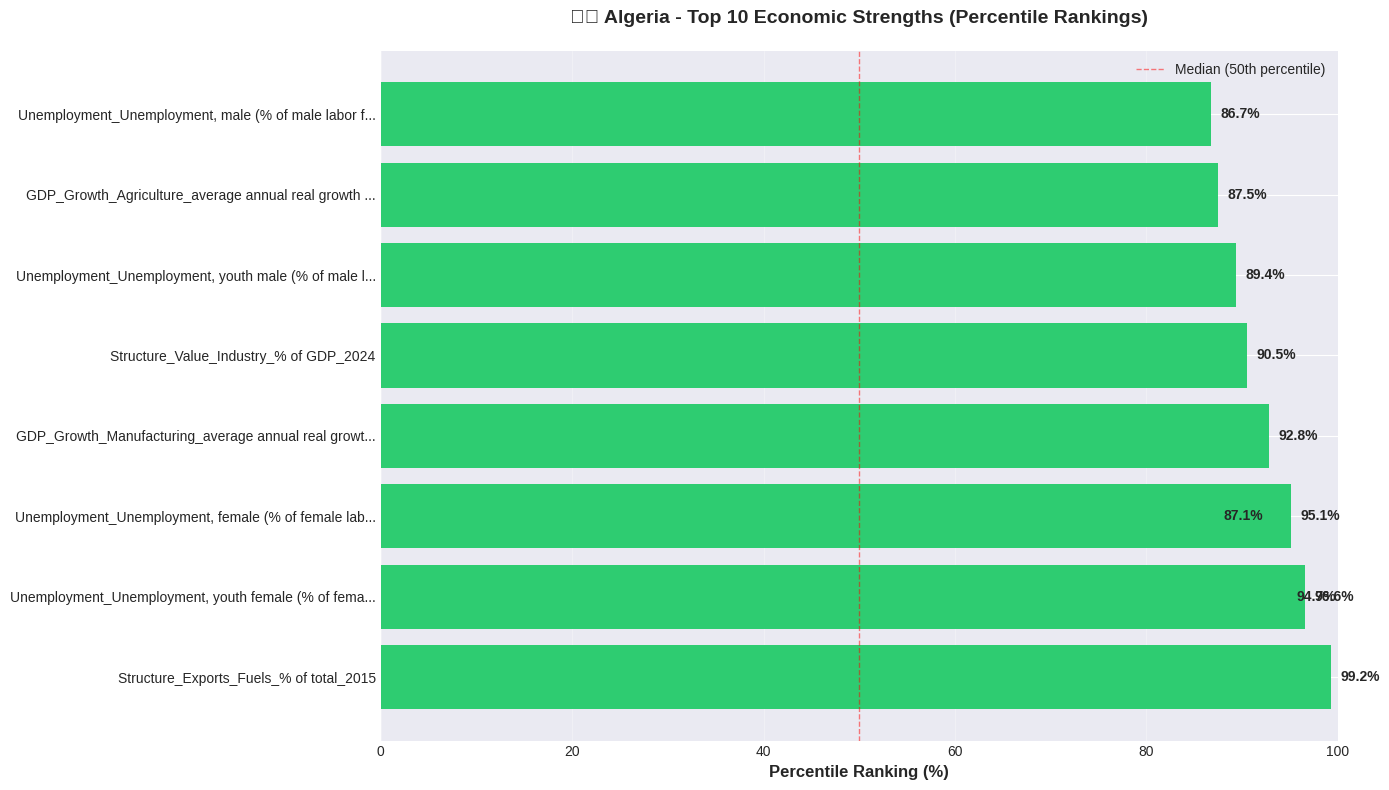

In [21]:
# Plot top 10 economic strengths
fig, ax = plt.subplots(figsize=(14, 8))

top_10_economic = algeria_economic_sorted.head(10)
indicators = [ind[:50] + '...' if len(ind) > 50 else ind for ind in top_10_economic['Indicator']]
percentiles = top_10_economic['Percentile']

bars = ax.barh(indicators, percentiles, color='#2ecc71')
ax.set_xlabel('Percentile Ranking (%)', fontsize=12, fontweight='bold')
ax.set_title('🇩🇿 Algeria - Top 10 Economic Strengths (Percentile Rankings)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Median (50th percentile)')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, percentiles)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('figures/algeria_economic_strengths.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures/algeria_economic_strengths.png')
plt.show()

### 5.2 Economic Indicators - Top Weaknesses

💾 Saved: figures/algeria_economic_weaknesses.png


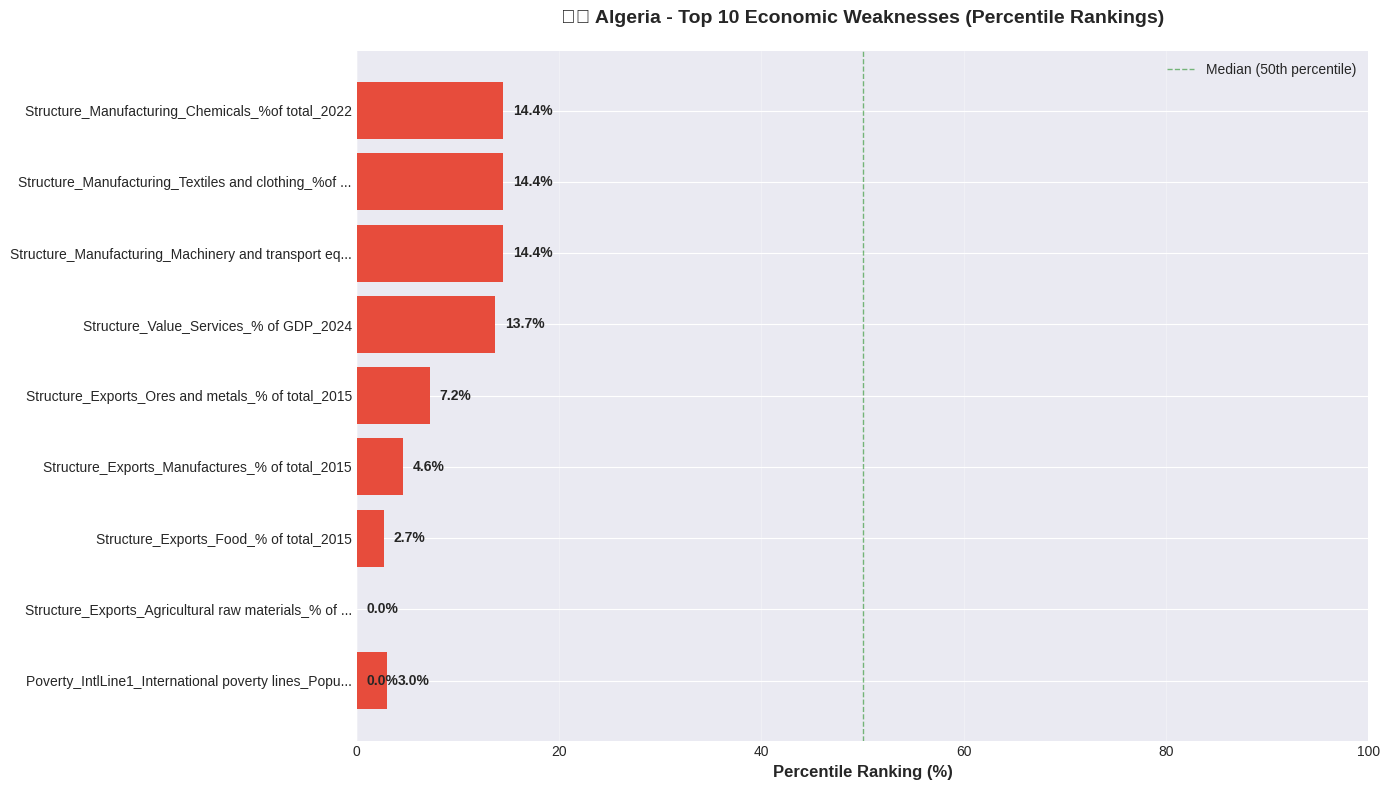

In [22]:
# Plot top 10 economic weaknesses
fig, ax = plt.subplots(figsize=(14, 8))

bottom_10_economic = algeria_economic_sorted.tail(10).sort_values('Percentile')
indicators = [ind[:50] + '...' if len(ind) > 50 else ind for ind in bottom_10_economic['Indicator']]
percentiles = bottom_10_economic['Percentile']

bars = ax.barh(indicators, percentiles, color='#e74c3c')
ax.set_xlabel('Percentile Ranking (%)', fontsize=12, fontweight='bold')
ax.set_title('🇩🇿 Algeria - Top 10 Economic Weaknesses (Percentile Rankings)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=50, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Median (50th percentile)')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, percentiles)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('figures/algeria_economic_weaknesses.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures/algeria_economic_weaknesses.png')
plt.show()

### 5.3 Resources & Human Capital - Top Strengths

💾 Saved: figures/algeria_resources_strengths.png


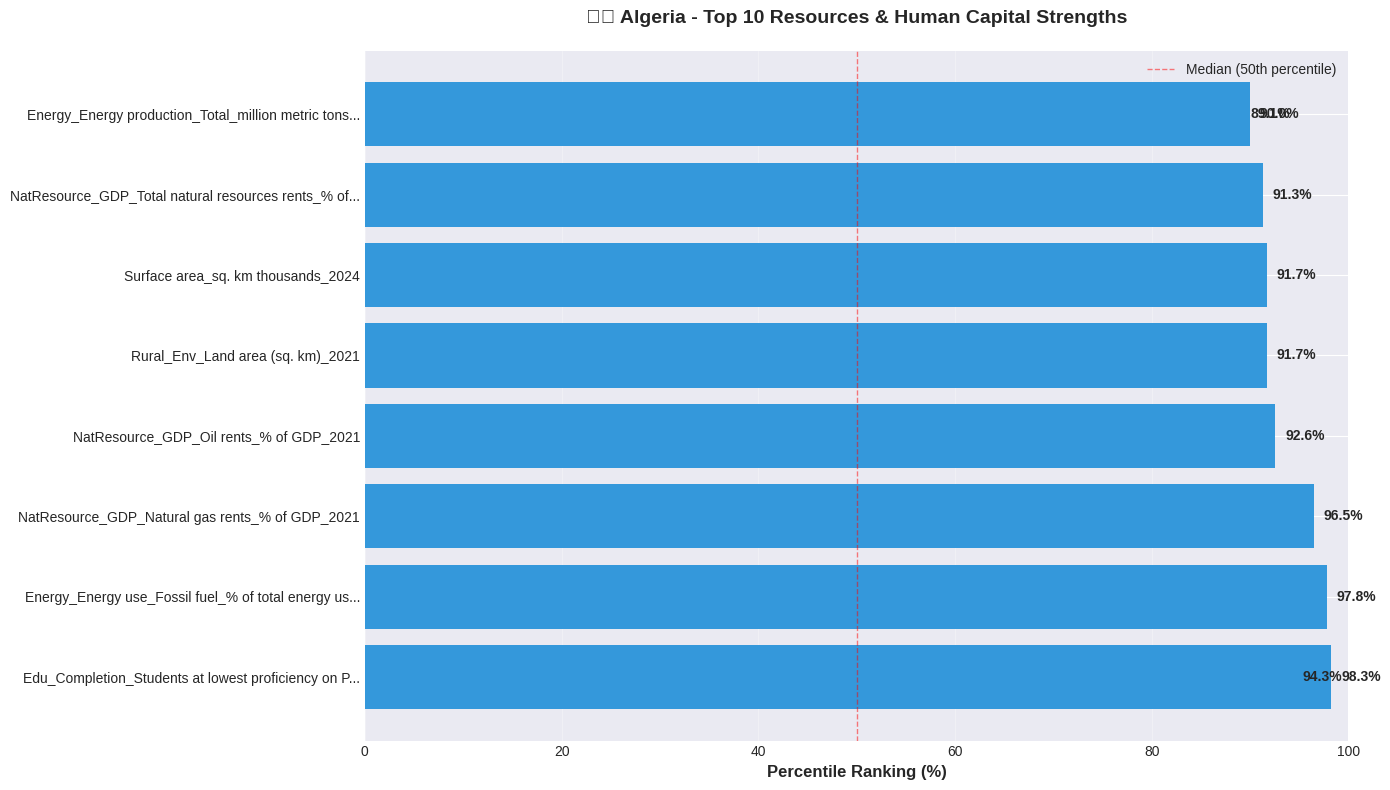

In [23]:
# Plot top 10 resources strengths
fig, ax = plt.subplots(figsize=(14, 8))

top_10_resources = algeria_resources_sorted.head(10)
indicators = [ind[:50] + '...' if len(ind) > 50 else ind for ind in top_10_resources['Indicator']]
percentiles = top_10_resources['Percentile']

bars = ax.barh(indicators, percentiles, color='#3498db')
ax.set_xlabel('Percentile Ranking (%)', fontsize=12, fontweight='bold')
ax.set_title('🇩🇿 Algeria - Top 10 Resources & Human Capital Strengths', 
             fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Median (50th percentile)')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, percentiles)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('figures/algeria_resources_strengths.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures/algeria_resources_strengths.png')
plt.show()

### 5.4 Resources & Human Capital - Top Weaknesses

💾 Saved: figures/algeria_resources_weaknesses.png


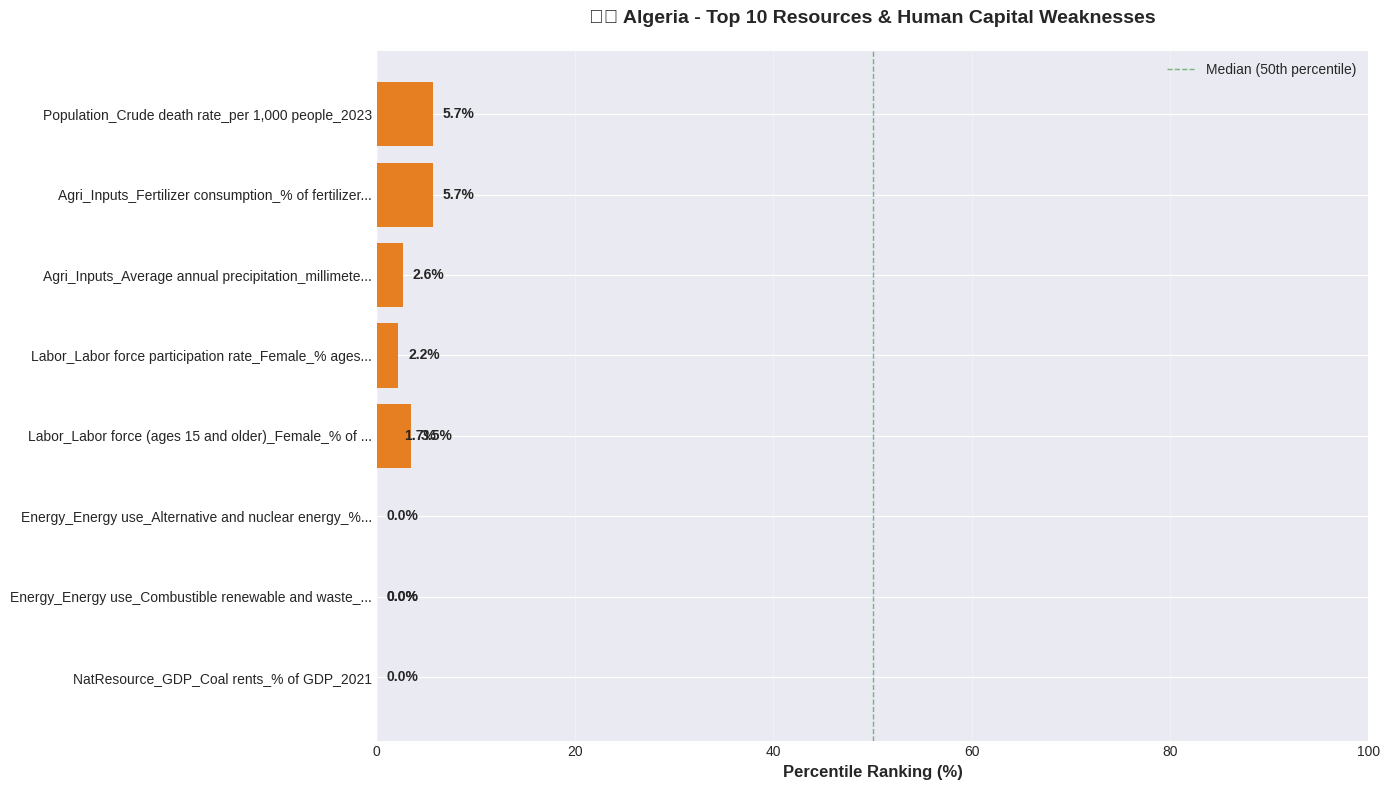

In [24]:
# Plot top 10 resources weaknesses
fig, ax = plt.subplots(figsize=(14, 8))

bottom_10_resources = algeria_resources_sorted.tail(10).sort_values('Percentile')
indicators = [ind[:50] + '...' if len(ind) > 50 else ind for ind in bottom_10_resources['Indicator']]
percentiles = bottom_10_resources['Percentile']

bars = ax.barh(indicators, percentiles, color='#e67e22')
ax.set_xlabel('Percentile Ranking (%)', fontsize=12, fontweight='bold')
ax.set_title('🇩🇿 Algeria - Top 10 Resources & Human Capital Weaknesses', 
             fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=50, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Median (50th percentile)')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, percentiles)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('figures/algeria_resources_weaknesses.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures/algeria_resources_weaknesses.png')
plt.show()

## 6. Overall Performance Distribution

### 6.1 Economic Indicators Distribution

💾 Saved: figures/algeria_performance_distribution.png


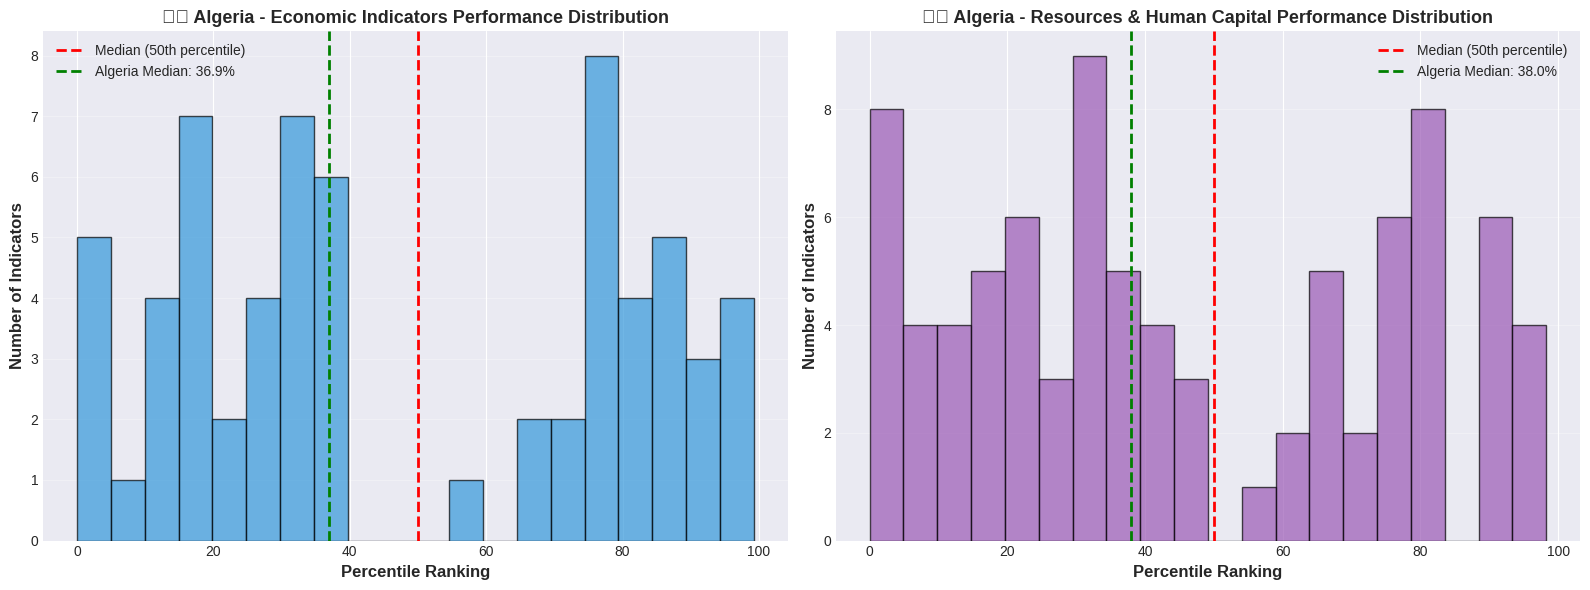


📊 SUMMARY STATISTICS


🏆 Economic Indicators:
   Mean Percentile: 48.3%
   Median Percentile: 36.9%
   Above 50th percentile: 29 indicators
   Below 50th percentile: 36 indicators

🏆 Resources & Human Capital:
   Mean Percentile: 45.6%
   Median Percentile: 38.0%
   Above 50th percentile: 34 indicators
   Below 50th percentile: 51 indicators


In [25]:
# Create histogram of percentile rankings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Economic indicators histogram
ax1.hist(algeria_economic_rankings['Percentile'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Median (50th percentile)')
ax1.axvline(x=algeria_economic_rankings['Percentile'].median(), color='green', 
            linestyle='--', linewidth=2, label=f'Algeria Median: {algeria_economic_rankings["Percentile"].median():.1f}%')
ax1.set_xlabel('Percentile Ranking', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Indicators', fontsize=12, fontweight='bold')
ax1.set_title('🇩🇿 Algeria - Economic Indicators Performance Distribution', 
              fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Resources indicators histogram
ax2.hist(algeria_resources_rankings['Percentile'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
ax2.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Median (50th percentile)')
ax2.axvline(x=algeria_resources_rankings['Percentile'].median(), color='green', 
            linestyle='--', linewidth=2, label=f'Algeria Median: {algeria_resources_rankings["Percentile"].median():.1f}%')
ax2.set_xlabel('Percentile Ranking', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Indicators', fontsize=12, fontweight='bold')
ax2.set_title('🇩🇿 Algeria - Resources & Human Capital Performance Distribution', 
              fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/algeria_performance_distribution.png', dpi=300, bbox_inches='tight')
print('💾 Saved: figures/algeria_performance_distribution.png')
plt.show()

# Print summary statistics
print('\n📊 SUMMARY STATISTICS\n')
print('='*80)
print(f'\n🏆 Economic Indicators:')
print(f'   Mean Percentile: {algeria_economic_rankings["Percentile"].mean():.1f}%')
print(f'   Median Percentile: {algeria_economic_rankings["Percentile"].median():.1f}%')
print(f'   Above 50th percentile: {(algeria_economic_rankings["Percentile"] > 50).sum()} indicators')
print(f'   Below 50th percentile: {(algeria_economic_rankings["Percentile"] <= 50).sum()} indicators')

print(f'\n🏆 Resources & Human Capital:')
print(f'   Mean Percentile: {algeria_resources_rankings["Percentile"].mean():.1f}%')
print(f'   Median Percentile: {algeria_resources_rankings["Percentile"].median():.1f}%')
print(f'   Above 50th percentile: {(algeria_resources_rankings["Percentile"] > 50).sum()} indicators')
print(f'   Below 50th percentile: {(algeria_resources_rankings["Percentile"] <= 50).sum()} indicators')

## 7. Comparison with Regional Peers

### 7.1 Select Regional Peers (North African and Middle Eastern Countries)

In [26]:
# Define regional peers
regional_peers = ['Morocco', 'Tunisia', 'Egypt', 'Libya', 'Saudi Arabia', 'Turkey', 'Jordan']

# Find these countries in the economic dataset
peer_data_economic = []
for country in regional_peers:
    country_row = economic_df[economic_df['Country'].str.contains(country, case=False, na=False)]
    if len(country_row) > 0:
        peer_data_economic.append(country_row)

if len(peer_data_economic) > 0:
    peers_economic_df = pd.concat(peer_data_economic)
    peers_economic_df = pd.concat([algeria_economic, peers_economic_df])
    print(f'\n🌍 Found {len(peers_economic_df)} countries for economic comparison (including Algeria)')
    print(f'Countries: {list(peers_economic_df["Country"].values)}')
else:
    print('⚠️ No regional peers found in economic dataset')


🌍 Found 7 countries for economic comparison (including Algeria)
Countries: ['Algeria', 'Morocco', 'Tunisia', 'Egypt, Arab Rep.', 'Libya', 'Saudi Arabia', 'Jordan']


### 7.2 Compare Key Economic Indicators

💾 Saved: figures/algeria_regional_comparison.png


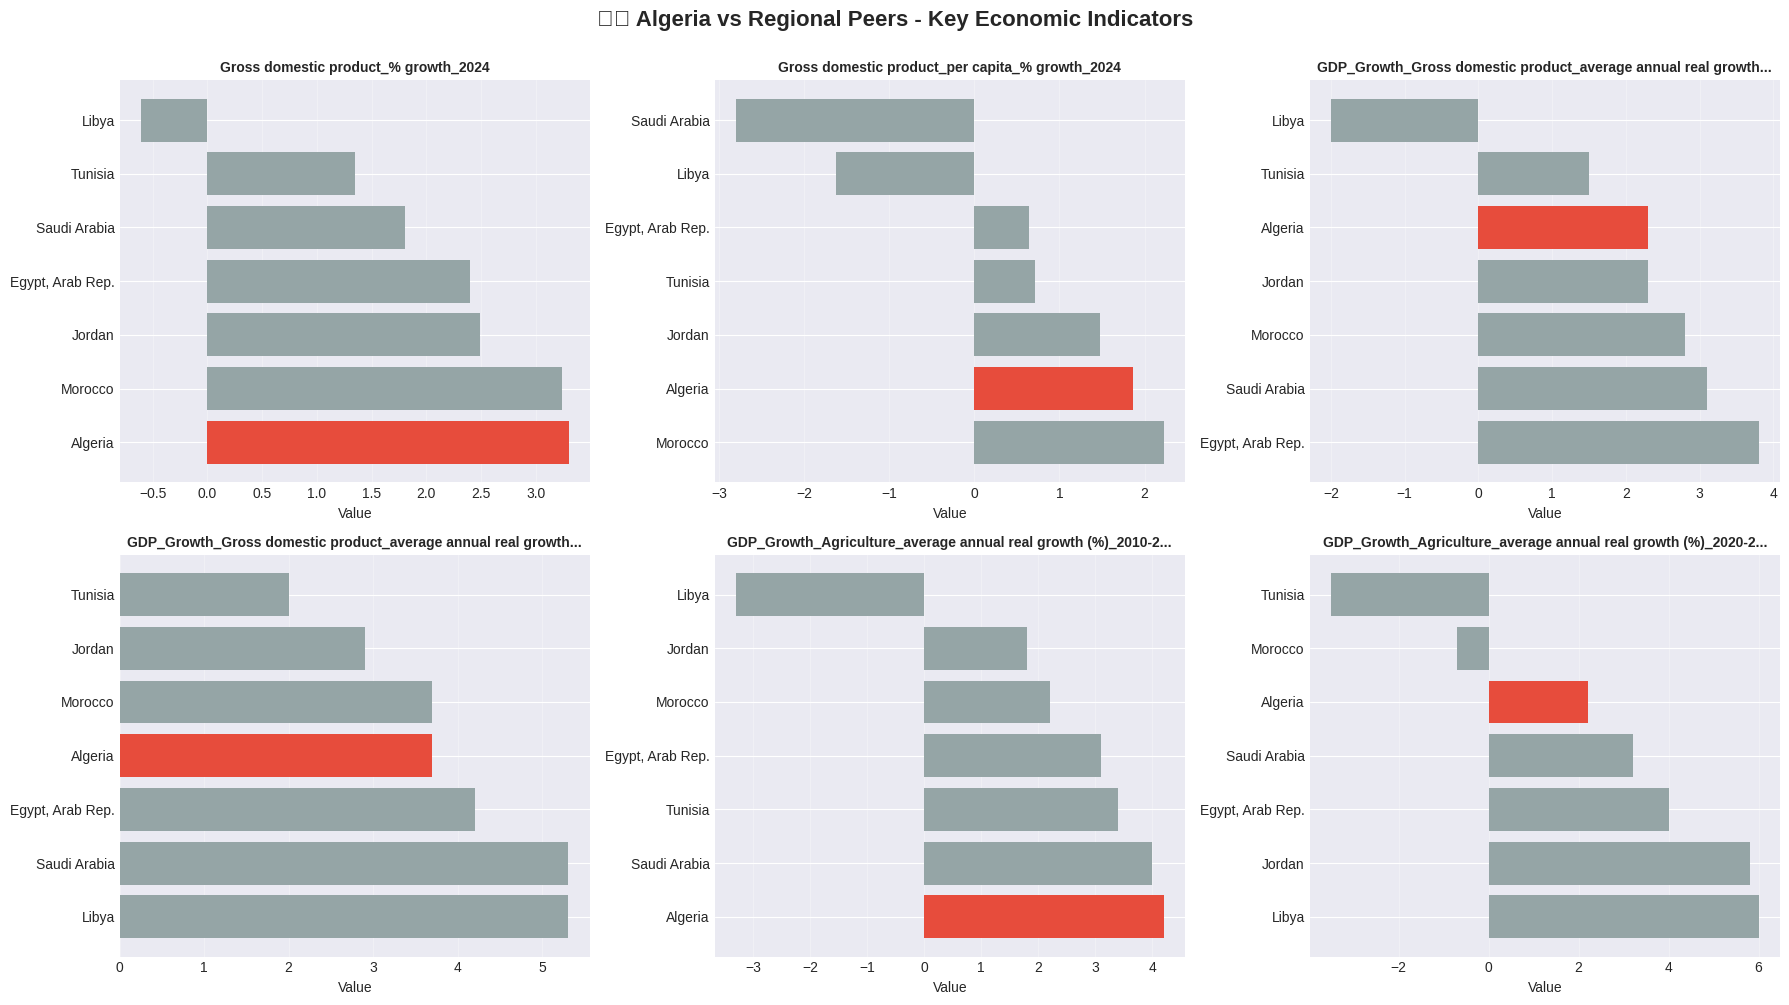

In [27]:
# Select a few key indicators for comparison
key_economic_indicators = [
    col for col in economic_df.columns 
    if any(keyword in col.lower() for keyword in ['gdp', 'growth', 'unemployment', 'poverty'])
][:8]  # Limit to first 8 matching indicators

if len(key_economic_indicators) > 0 and len(peer_data_economic) > 0:
    # Create comparison plot
    n_indicators = min(6, len(key_economic_indicators))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, indicator in enumerate(key_economic_indicators[:n_indicators]):
        ax = axes[idx]
        
        # Get data for this indicator
        plot_data = peers_economic_df[['Country', indicator]].copy()
        plot_data = plot_data.sort_values(indicator, ascending=False)
        
        # Create color list (highlight Algeria)
        colors = ['#e74c3c' if 'algeria' in str(country).lower() else '#95a5a6' 
                  for country in plot_data['Country']]
        
        # Plot
        bars = ax.barh(plot_data['Country'], plot_data[indicator], color=colors)
        ax.set_xlabel('Value', fontsize=10)
        ax.set_title(indicator[:60] + ('...' if len(indicator) > 60 else ''), 
                     fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Remove empty subplots
    for idx in range(n_indicators, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('🇩🇿 Algeria vs Regional Peers - Key Economic Indicators', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures/algeria_regional_comparison.png', dpi=300, bbox_inches='tight')
    print('💾 Saved: figures/algeria_regional_comparison.png')
    plt.show()
else:
    print('⚠️ Not enough data for comparison')

## 8. Export Results for Report

In [28]:
# Create summary report
summary_report = {
    'Economic_Top_Strengths': top_economic_strengths[['Indicator', 'Algeria_Value', 'Percentile']].to_dict('records'),
    'Economic_Top_Weaknesses': top_economic_weaknesses[['Indicator', 'Algeria_Value', 'Percentile']].to_dict('records'),
    'Resources_Top_Strengths': top_resources_strengths[['Indicator', 'Algeria_Value', 'Percentile']].to_dict('records'),
    'Resources_Top_Weaknesses': top_resources_weaknesses[['Indicator', 'Algeria_Value', 'Percentile']].to_dict('records')
}

# Save to CSV files
algeria_economic_rankings.to_csv('algeria_economic_rankings.csv', index=False)
algeria_resources_rankings.to_csv('algeria_resources_rankings.csv', index=False)

print('✅ Analysis complete!')
print('\n📁 Files saved:')
print('   - algeria_economic_rankings.csv')
print('   - algeria_resources_rankings.csv')
print('\n📊 Figures saved in figures/ directory:')
print('   - algeria_economic_strengths.png')
print('   - algeria_economic_weaknesses.png')
print('   - algeria_resources_strengths.png')
print('   - algeria_resources_weaknesses.png')
print('   - algeria_performance_distribution.png')
print('   - algeria_regional_comparison.png')
print('\n💡 Use these rankings and figures in your report to identify areas for policy intervention and development strategies.')

✅ Analysis complete!

📁 Files saved:
   - algeria_economic_rankings.csv
   - algeria_resources_rankings.csv

📊 Figures saved in figures/ directory:
   - algeria_economic_strengths.png
   - algeria_economic_weaknesses.png
   - algeria_resources_strengths.png
   - algeria_resources_weaknesses.png
   - algeria_performance_distribution.png
   - algeria_regional_comparison.png

💡 Use these rankings and figures in your report to identify areas for policy intervention and development strategies.


## 9. Key Findings Summary

### Good Indicators (Strengths):
- Review the visualizations above to identify Algeria's top-performing indicators
- Indicators with percentile > 70% represent significant strengths
- These areas can serve as foundations for economic development strategies

### Bad Indicators (Weaknesses):
- Indicators with percentile < 30% represent areas needing improvement
- These should be prioritized in policy interventions
- Comparison with regional peers helps identify realistic improvement targets

### Overall Performance:
- Check the distribution histograms to understand Algeria's overall positioning
- The median percentile indicates whether Algeria performs above or below average globally
- Balance between economic performance and resource/human capital development is crucial